# 🧬 Ingeniería de MSA y Dominios (Caso T1266)

Este notebook utiliza los datos experimentales para demostrar cómo el muestreo de múltiples fuentes de MSA, sumado al particionamiento de dominios asimétricos, mejora drásticamente las predicciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos GDT-TS para el dominio T1266-D1 donde ocurre la ingeniería
df_t1266 = pd.read_csv(r'zenodo/Labels/GDT-TS/T1266-D1.csv')
df_t1266.head()

,Unnamed: 0,model,tmscore
0,0,af3_jian_0,81.271
1,1,af3_jian_1,82.373
2,2,af3_jian_2,83.220
3,3,af3_jian_3,83.220
4,4,af3_jian_4,87.966


## 1. Impacto de Fuentes de Alineamientos (MSA)
MULTICOM ensambla modelos desde ColabFold, DeepMSA, ESMFold y perfiles de base de datos DHR. Aquí graficamos el GDT-TS máximo que logra cada fuente para este objetivo específico.

C:\Users\user\AppData\Local\Temp\ipykernel_1472\1687959463.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MSA_Source', y='tmscore', data=best_by_source, palette='Set2')


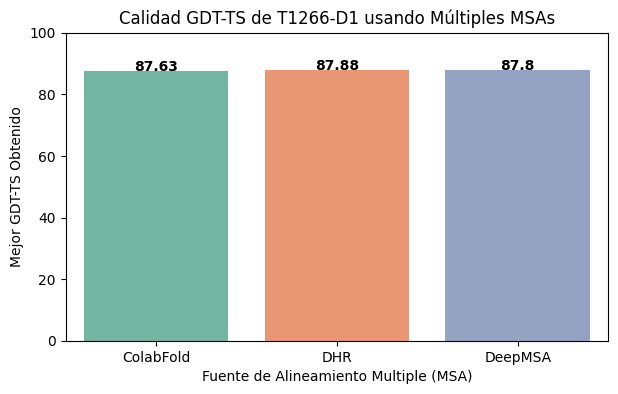

In [2]:
def categorize_msa(model_name):
    if model_name.startswith('colabfold'): return 'ColabFold'
    if model_name.startswith('deepmsa'): return 'DeepMSA'
    if model_name.startswith('dhr'): return 'DHR'
    if model_name.startswith('esmfold'): return 'ESMFold'
    if 'dom' in model_name: return 'Domain_Parsing'
    return 'Other'

df_t1266['MSA_Source'] = df_t1266['model'].apply(categorize_msa)

sources_to_compare = ['ColabFold', 'DeepMSA', 'DHR', 'ESMFold']
source_data = df_t1266[df_t1266['MSA_Source'].isin(sources_to_compare)]
best_by_source = source_data.groupby('MSA_Source')['tmscore'].max().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(x='MSA_Source', y='tmscore', data=best_by_source, palette='Set2')
plt.title('Calidad GDT-TS de T1266-D1 usando Múltiples MSAs')
plt.xlabel('Fuente de Alineamiento Multiple (MSA)')
plt.ylabel('Mejor GDT-TS Obtenido')
plt.ylim(0, 100)
for i, v in enumerate(best_by_source['tmscore']):
    plt.text(i, v + 0.02, str(round(v, 2)), ha='center', fontweight='bold')
plt.show()

## 2. El Poder del Modelado Basado en Dominios
Para T1266, el objetivo consta de dominios con diferentes arquitecturas. En lugar de predecir la cadena completa y fallar en el dominio 1, MULTICOM fuerza predicciones usando recortes (crops) de dominios. El análisis muestra cuán superior es el modelo dominiocéntrico.

--- Análisis del Efecto de Particionamiento de Dominio ---
Mejor modelo estándar basado en cadena completa (Colab/DeepMSA/DHR): 87.881 GDT-TS
Mejor modelo basado en ingeniería y particionamiento de sub-dominios: 88.559 GDT-TS


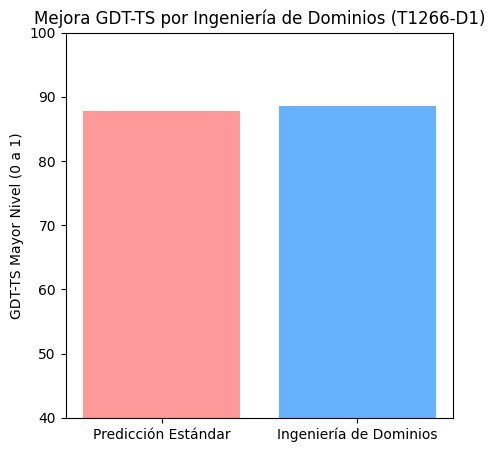

In [3]:
domain_parsing = df_t1266[df_t1266['MSA_Source'] == 'Domain_Parsing']['tmscore'].max()
standard_baseline = source_data['tmscore'].max()

print('--- Análisis del Efecto de Particionamiento de Dominio ---')
print(f'Mejor modelo estándar basado en cadena completa (Colab/DeepMSA/DHR): {standard_baseline:.3f} GDT-TS')
if not pd.isna(domain_parsing):
    print(f'Mejor modelo basado en ingeniería y particionamiento de sub-dominios: {domain_parsing:.3f} GDT-TS')
    
    # Plot direct comparison
    plt.figure(figsize=(5, 5))
    plt.bar(['Predicción Estándar', 'Ingeniería de Dominios'], 
            [standard_baseline, domain_parsing], 
            color=['#FF9999', '#66B2FF'])
    plt.title('Mejora GDT-TS por Ingeniería de Dominios (T1266-D1)')
    plt.ylabel('GDT-TS Mayor Nivel (0 a 1)')
    plt.ylim(40, 100)
    plt.show()